# Forward Testing

Loading datasets...

Training Set Profiles (2020-2025):
 - Low/Moderate Risk samples: 4405
 - High Risk samples: 2171
 - Calculated scale_pos_weight: 2.0290

Training XGBoost Classifier on Historical Data...
Training complete!

Evaluating on Future Dataset (2026-2030)...

================ CLASSICAL XGBOOST FUTURE EVALUATION ================
Overall Accuracy: 0.8682

Detailed Classification Report:
              precision    recall  f1-score   support

Low/Mod Risk       0.94      0.86      0.90      3663
   High Risk       0.76      0.88      0.82      1815

    accuracy                           0.87      5478
   macro avg       0.85      0.87      0.86      5478
weighted avg       0.88      0.87      0.87      5478


Confusion matrix visualization saved successfully as 'future_eval_conf_matrix.png'!


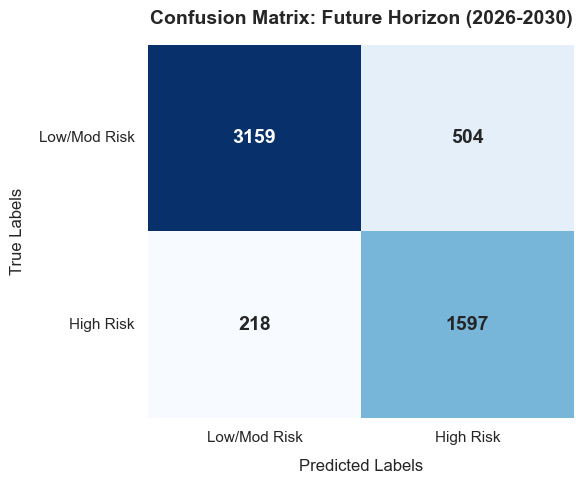

In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ---------------------------------------------------------
# 1. Load Datasets
# ---------------------------------------------------------
print("Loading datasets...")
# Replace with your actual historical filename
df_train = pd.read_csv('modified-shuffled.csv')  
# Your new future dataset containing 2026-2030 features AND labels
df_test = pd.read_csv('modified-shuffled-future-only.csv')    

features_to_use = [
    'wave_height', 'wave_period', 'wave_direction', 
    'precipitation', 'wind_speed', 'tidal_height_m'
]

# Extract features
X_train = df_train[features_to_use].values
X_test = df_test[features_to_use].values

# Map targets to binary format (0: Low/Mod, 1: High)
y_train = df_train['erosion_risk'].apply(lambda x: 1 if x in ['High', 'High Risk'] else 0).values
y_test = df_test['erosion_risk'].apply(lambda x: 1 if x in ['High', 'High Risk'] else 0).values

# ---------------------------------------------------------
# 2. Strict Scale Isolation (Prevent Data Leakage)
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transform only using train parameters

# Calculate exact class imbalance ratio directly from the 2020-2025 training set
num_low_mod = np.sum(y_train == 0)
num_high = np.sum(y_train == 1)
imbalance_ratio = num_low_mod / num_high

print(f"\nTraining Set Profiles (2020-2025):")
print(f" - Low/Moderate Risk samples: {num_low_mod}")
print(f" - High Risk samples: {num_high}")
print(f" - Calculated scale_pos_weight: {imbalance_ratio:.4f}")

# ---------------------------------------------------------
# 3. Train XGBoost Classifier
# ---------------------------------------------------------
print("\nTraining XGBoost Classifier on Historical Data...")
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio, # Penalize minority class errors
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)
print("Training complete!")

# ---------------------------------------------------------
# 4. Evaluation & Predictions on Future Window (2026-2030)
# ---------------------------------------------------------
print("\nEvaluating on Future Dataset (2026-2030)...")
y_pred = xgb_model.predict(X_test_scaled)

print("\n================ CLASSICAL XGBOOST FUTURE EVALUATION ================")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("=====================================================================")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low/Mod Risk', 'High Risk']))

# ---------------------------------------------------------
# 5. Generate and Plot Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Low/Mod Risk', 'High Risk'], 
    yticklabels=['Low/Mod Risk', 'High Risk'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Confusion Matrix: Future Horizon (2026-2030)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Predicted Labels', fontsize=12, labelpad=10)
plt.ylabel('True Labels', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()

# Save matrix graphic
plt.savefig('future_eval_conf_matrix.png', dpi=300)
print("\nConfusion matrix visualization saved successfully as 'future_eval_conf_matrix.png'!")
plt.show()

# Backtesting

Loading datasets...

Training Set Profiles (2020-2025):
 - Low/Moderate Risk samples: 3663
 - High Risk samples: 1815
 - Calculated scale_pos_weight: 2.0182

Training XGBoost Classifier on Historical Data...
Training complete!

Evaluating on Future Dataset (2026-2030)...

================ CLASSICAL XGBOOST FUTURE EVALUATION ================
Overall Accuracy: 0.8312

Detailed Classification Report:
              precision    recall  f1-score   support

Low/Mod Risk       0.91      0.83      0.87      4405
   High Risk       0.71      0.83      0.76      2171

    accuracy                           0.83      6576
   macro avg       0.81      0.83      0.82      6576
weighted avg       0.84      0.83      0.83      6576


Confusion matrix visualization saved successfully as 'future_eval_conf_matrix.png'!


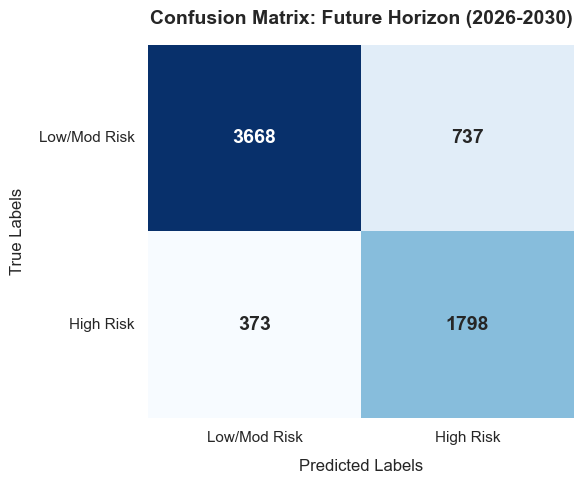

In [11]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ---------------------------------------------------------
# 1. Load Datasets
# ---------------------------------------------------------
print("Loading datasets...")
# Replace with your actual historical filename
df_test = pd.read_csv('modified-shuffled.csv')  
# Your new future dataset containing 2026-2030 features AND labels
df_train = pd.read_csv('modified-shuffled-future-only.csv')    

features_to_use = [
    'wave_height', 'wave_period', 'wave_direction', 
    'precipitation', 'wind_speed', 'tidal_height_m'
]

# Extract features
X_train = df_train[features_to_use].values
X_test = df_test[features_to_use].values

# Map targets to binary format (0: Low/Mod, 1: High)
y_train = df_train['erosion_risk'].apply(lambda x: 1 if x in ['High', 'High Risk'] else 0).values
y_test = df_test['erosion_risk'].apply(lambda x: 1 if x in ['High', 'High Risk'] else 0).values

# ---------------------------------------------------------
# 2. Strict Scale Isolation (Prevent Data Leakage)
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transform only using train parameters

# Calculate exact class imbalance ratio directly from the 2020-2025 training set
num_low_mod = np.sum(y_train == 0)
num_high = np.sum(y_train == 1)
imbalance_ratio = num_low_mod / num_high

print(f"\nTraining Set Profiles (2020-2025):")
print(f" - Low/Moderate Risk samples: {num_low_mod}")
print(f" - High Risk samples: {num_high}")
print(f" - Calculated scale_pos_weight: {imbalance_ratio:.4f}")

# ---------------------------------------------------------
# 3. Train XGBoost Classifier
# ---------------------------------------------------------
print("\nTraining XGBoost Classifier on Historical Data...")
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio, # Penalize minority class errors
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)
print("Training complete!")

# ---------------------------------------------------------
# 4. Evaluation & Predictions on Future Window (2026-2030)
# ---------------------------------------------------------
print("\nEvaluating on Future Dataset (2026-2030)...")
y_pred = xgb_model.predict(X_test_scaled)

print("\n================ CLASSICAL XGBOOST FUTURE EVALUATION ================")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("=====================================================================")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low/Mod Risk', 'High Risk']))

# ---------------------------------------------------------
# 5. Generate and Plot Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.set_theme(style="white")

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Low/Mod Risk', 'High Risk'], 
    yticklabels=['Low/Mod Risk', 'High Risk'],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Confusion Matrix: Future Horizon (2026-2030)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Predicted Labels', fontsize=12, labelpad=10)
plt.ylabel('True Labels', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()

# Save matrix graphic
plt.savefig('future_eval_conf_matrix.png', dpi=300)
print("\nConfusion matrix visualization saved successfully as 'future_eval_conf_matrix.png'!")
plt.show()

Heatmap matrix successfully generated and saved as 'temporal_validation_heatmap.png'!


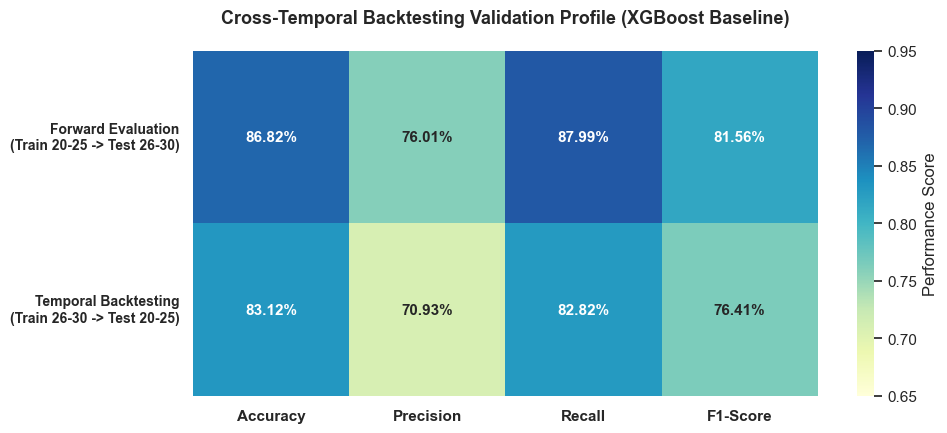

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. Data Extracted From Your Confusion Matrices
# ---------------------------------------------------------
tn1, fp1, fn1, tp1 = 3159, 504, 218, 1597
acc1 = (tp1 + tn1) / (tn1 + fp1 + fn1 + tp1)
prec1 = tp1 / (tp1 + fp1)
rec1 = tp1 / (tp1 + fn1)
f1_1 = 2 * (prec1 * rec1) / (prec1 + rec1)

tn2, fp2, fn2, tp2 = 3668, 737, 373, 1798
acc2 = (tp2 + tn2) / (tn2 + fp2 + fn2 + tp2)
prec2 = tp2 / (tp2 + fp2)
rec2 = tp2 / (tp2 + fn2)
f1_2 = 2 * (prec2 * rec2) / (prec2 + rec2)

# Create a structured DataFrame for Seaborn
data = np.array([
    [acc1, prec1, rec1, f1_1],
    [acc2, prec2, rec2, f1_2]
])

evaluation_phases = [
    'Forward Evaluation\n(Train 20-25 -> Test 26-30)', 
    'Temporal Backtesting\n(Train 26-30 -> Test 20-25)'
]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

df = pd.DataFrame(data, index=evaluation_phases, columns=metrics)

# ---------------------------------------------------------
# 2. Plotting the Heatmap Matrix
# ---------------------------------------------------------
sns.set_theme(style="white")
plt.figure(figsize=(10, 4.5))

# Using the 'YlGnBu' (Yellow-Green-Blue) palette for a clean academic look
# vmin/vmax locks the color scale to standard classification ranges
ax = sns.heatmap(
    df, 
    annot=True, 
    fmt=".2%", 
    cmap="YlGnBu", 
    vmin=0.65, 
    vmax=0.95, 
    cbar_kws={'label': 'Performance Score'},
    annot_kws={"weight": "bold", "size": 11}
)

# ---------------------------------------------------------
# 3. Aesthetics & Fine Tuning
# ---------------------------------------------------------
plt.title('Cross-Temporal Backtesting Validation Profile (XGBoost Baseline)', fontsize=13, weight='bold', pad=20)
plt.xticks(fontsize=11, weight='bold')
plt.yticks(fontsize=10, rotation=0, weight='bold') # Kept horizontal for easier reading

# Adjust layout to prevent label clipping
plt.tight_layout()

# Save matrix image for report
plt.savefig('temporal_validation_heatmap.png', dpi=300)
print("Heatmap matrix successfully generated and saved as 'temporal_validation_heatmap.png'!")

plt.show()